# Titanic Survival Classification
**Saad Kabeer | Machine Learning Project**

An end-to-end classification project that predicts passenger survival from demographic and travel information. The workflow covers data validation, exploratory analysis, feature engineering, preprocessing pipelines, cross-validation, hyperparameter tuning, and held-out evaluation.

The target is `Survived`: **0 = did not survive; 1 = survived**.

### Results at a glance
The saved run selected **Gradient Boosting with simple features and tuned hyperparameters**, with **83.70% mean cross-validation accuracy** and **81.01% test accuracy (145 of 179 passengers)**. These are separate measurements: cross-validation supports model selection, while the test set evaluates the selected model.

### Run the notebook
1. Open the notebook in Google Colab or Jupyter.
2. Place `titanic_dataset.csv` beside the notebook, in `data/`, or in Colab's `/content/` directory. The dataset is supplied separately.
3. Select **Run all**. Colab prompts for an upload if the CSV is not found; in Jupyter, set `DATA_PATH` if needed.
4. Allow several minutes for cross-validation and tuning on a CPU. A GPU is not required.

The saved outputs document the author-provided rerun after the title-extraction correction. All 18 code cells have sequential execution counts and no saved error outputs. Package versions and the exact dataset can affect reproducibility.

## 1. Environment and reproducibility

Import the analysis and modeling libraries, define the random seed and evaluation settings, and record package versions. Warnings remain visible to help identify compatibility or convergence issues.

The recorded environment uses Python 3.13.15, NumPy 2.1.3, pandas 2.2.3, scikit-learn 1.6.1, Matplotlib 3.10.0, and Seaborn 0.13.2. The optional installation cell lists these versions for a dedicated environment. Restart the kernel after changing packages.

In [1]:
# Optional setup in a dedicated Python 3.13 environment:
# %pip install numpy==2.1.3 pandas==2.2.3 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2

In [2]:
from pathlib import Path
import hashlib
import json
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 101                    # Fixed in advance; never search for a lucky split.
TEST_SIZE = 0.20
CV_FOLDS = 5
SEARCH_ITERATIONS = 16         # Bounded search for each of the two CV leaders.
N_JOBS = 2                    # Set to 1 on a low-memory computer.

np.random.seed(SEED)
warnings.simplefilter('default')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (9, 5), 'figure.dpi': 110})
pd.set_option('display.max_columns', 20)

versions = {
    'python': platform.python_version(), 'numpy': np.__version__,
    'pandas': pd.__version__, 'scikit-learn': sklearn.__version__,
    'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__,
}
display(pd.Series(versions, name='Version').to_frame())

,Version
python,3.13.15
numpy,2.1.3
pandas,2.2.3
scikit-learn,1.6.1
matplotlib,3.10.0
seaborn,0.13.2


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Data loading and validation

Load the passenger CSV, record its SHA-256 fingerprint, and inspect its structure. Validation checks required columns, binary target labels, unique passenger identifiers, and valid numeric values before modeling.

The loading cell checks common local and Colab paths. It does not download or substitute a dataset.

In [3]:
DATA_PATH = None  # Example: Path('/content/titanic_dataset.csv') or Path('data/titanic_dataset.csv')

if DATA_PATH is None:
    candidates = [Path('titanic_dataset.csv'), Path('data/titanic_dataset.csv'),
                  Path('/content/titanic_dataset.csv')]
    DATA_PATH = next((p for p in candidates if p.is_file()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            'Place titanic_dataset.csv beside the notebook, or set DATA_PATH to its full path.'
        )
    print('Upload your titanic_dataset.csv file.')
    uploaded = files.upload()
    csv_names = [name for name in uploaded if name.lower().endswith('.csv')]
    if len(csv_names) != 1:
        raise ValueError('Upload exactly one training CSV, then rerun this cell.')
    DATA_PATH = Path(csv_names[0])

DATA_PATH = Path(DATA_PATH)
raw = pd.read_csv(DATA_PATH)
data_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('File:', DATA_PATH.name)
print('SHA-256:', data_sha256)
print('Shape:', raw.shape)
display(raw.head())

File: titanic_dataset.csv
SHA-256: 9c51ae2abda7ea3b27553a5e9b68d2778d38c3dc208dba42b5ec8ad3bd61a165
Shape: (891, 12)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
REQUIRED = ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
            'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
missing_columns = sorted(set(REQUIRED) - set(raw.columns))
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')
if raw['Survived'].isna().any() or set(raw['Survived'].unique()) != {0, 1}:
    raise ValueError('Training data must contain both target classes, 0 and 1, with no missing labels.')
if raw['PassengerId'].isna().any() or raw['PassengerId'].duplicated().any():
    raise ValueError('PassengerId must be present and unique. Investigate duplicates before splitting.')
for col in ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']:
    if not pd.api.types.is_numeric_dtype(raw[col]):
        raise TypeError(f'{col} must be numeric.')
    values = raw[col].dropna()
    if not np.isfinite(values).all() or (values < 0).any():
        raise ValueError(f'Investigate invalid {col} values before modeling.')
if not raw['Pclass'].isin([1, 2, 3]).all():
    raise ValueError('Pclass must be 1, 2 or 3.')

inspection = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'missing_count': raw.isna().sum(),
    'missing_pct': raw.isna().mean().mul(100).round(2),
    'unique_non_missing': raw.nunique(),
})
display(inspection)
print('Exact duplicate rows:', raw.duplicated().sum())
raw.info()

,dtype,missing_count,missing_pct,unique_non_missing
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,object,0,0.00,891
Sex,object,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,object,0,0.00,681
Fare,float64,0,0.00,248


Exact duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Training and test split

Reserve 20% of passengers for final evaluation using a fixed, stratified split. The saved run contains **712 training passengers and 179 test passengers**. Missing feature values are handled later in the pipelines, so all 891 rows are retained.

Exploratory analysis below uses the training partition. Model fitting and selection do not use test labels. Interpretation remains limited by the small historical dataset, prior exploration of the full dataset, and related family or ticket groups that may appear in both partitions.

In [5]:
X = raw.drop(columns='Survived').copy()
y = raw['Survived'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)
assert set(X_train['PassengerId']).isdisjoint(set(X_test['PassengerId']))
assert 'Survived' not in X_train.columns
print(f'Training passengers: {len(X_train)} | Test passengers: {len(X_test)}')
print('Training survival proportions:')
display(y_train.value_counts(normalize=True).sort_index().rename('proportion').to_frame())

# EDA below uses only the training partition.
train_eda = X_train.join(y_train)
display(train_eda[['Age', 'Fare', 'SibSp', 'Parch']].describe().round(2))

Training passengers: 712 | Test passengers: 179
Training survival proportions:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,proportion
Survived,
0,0.616573
1,0.383427


,Age,Fare,SibSp,Parch
count,573.00,712.00,712.00,712.00
mean,29.64,32.63,0.53,0.40
std,14.36,49.33,1.11,0.85
min,0.42,0.00,0.00,0.00
25%,20.00,7.92,0.00,0.00
50%,28.00,14.50,0.00,0.00
75%,38.00,31.28,1.00,0.00
max,80.00,512.33,8.00,6.00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4. Exploratory data analysis

Examine age and fare distributions, age by passenger class, and survival rates by sex and class using training data. Survival bars represent proportions rather than counts. Extreme ages and fares are retained when they are valid observations.

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


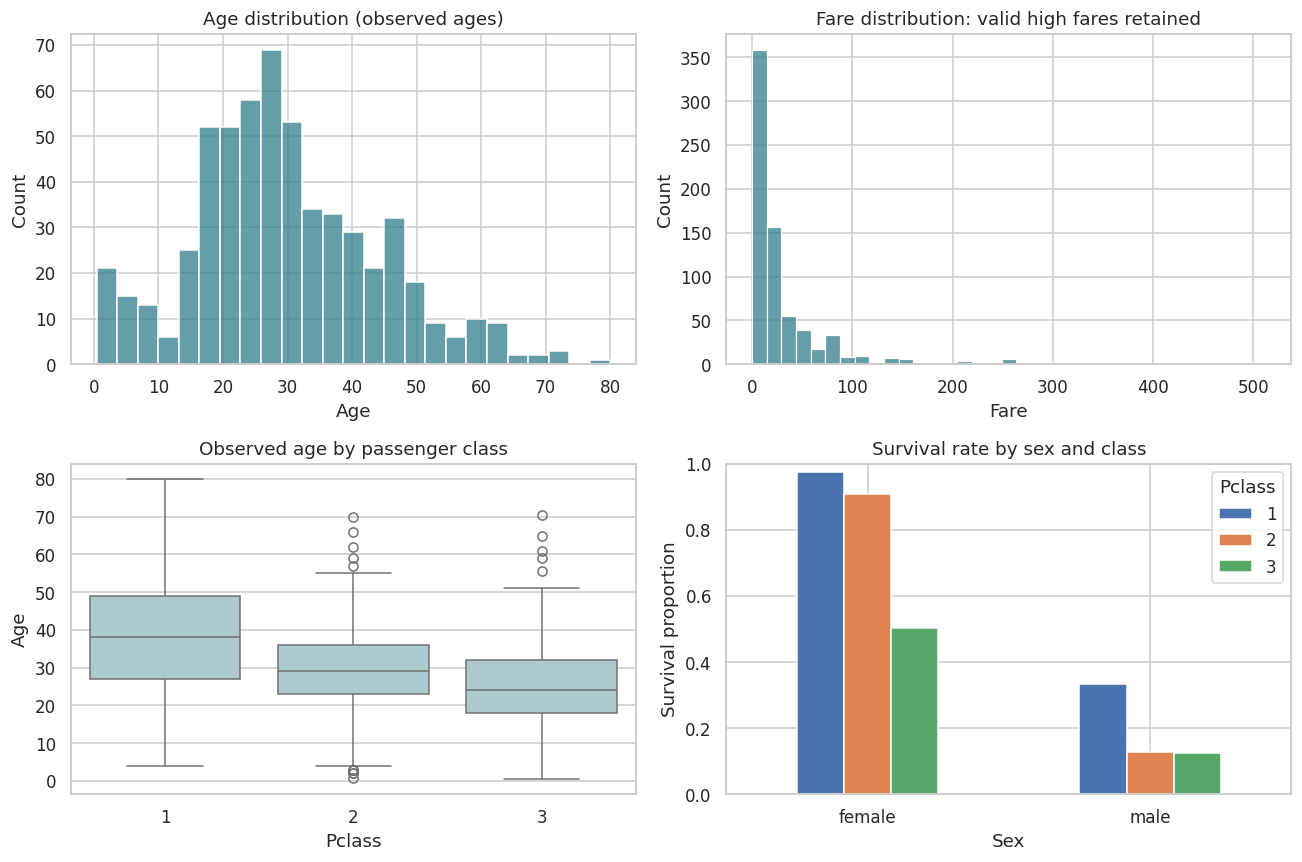

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=train_eda, x='Age', bins=25, ax=axes[0, 0], color='#327d8c')
axes[0, 0].set_title('Age distribution (observed ages)')
sns.histplot(data=train_eda, x='Fare', bins=35, ax=axes[0, 1], color='#327d8c')
axes[0, 1].set_title('Fare distribution: valid high fares retained')
sns.boxplot(data=train_eda, x='Pclass', y='Age', ax=axes[1, 0], color='#a6ced4')
axes[1, 0].set_title('Observed age by passenger class')
rates = train_eda.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
rates.plot.bar(ax=axes[1, 1], rot=0)
axes[1, 1].set(title='Survival rate by sex and class', ylabel='Survival proportion', ylim=(0, 1))
axes[1, 1].legend(title='Pclass')
plt.tight_layout()
plt.show()

### Correlation and missing values

The correlation heatmap uses selected numerical columns and excludes passenger identifiers. Pearson correlation describes linear association; it does not establish causation or capture every useful relationship. Interpret the ordinal `Pclass` and binary `Survived` codes accordingly.

The separate missingness heatmap shows where values are absent across the training features. These gaps are handled by the preprocessing pipeline.

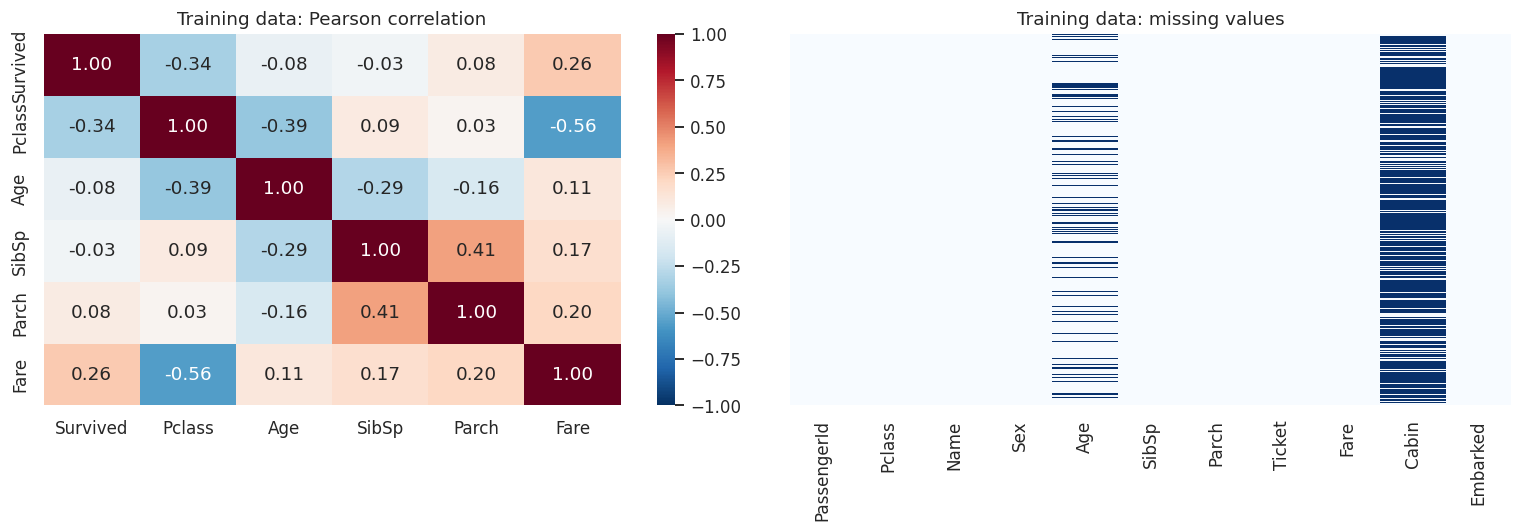

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
corr_columns = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train_eda[corr_columns].select_dtypes(include=np.number).corr()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', ax=axes[0])
axes[0].set_title('Training data: Pearson correlation')
sns.heatmap(X_train.isna(), yticklabels=False, cbar=False, cmap='Blues', ax=axes[1])
axes[1].set_title('Training data: missing values')
plt.tight_layout()
plt.show()

## 5. Feature construction

Compare a simple feature set with an engineered feature set. Derived features are calculated from each passenger's own row without using survival labels.

| Feature | Definition |
|---|---|
| Simple features | `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked` |
| `FamilySize` | `SibSp + Parch + 1` |
| `IsAlone` | Whether family size equals one |
| `FarePerPerson` | Fare divided by listed family size; an approximation, not the actual per-ticket fare |
| `Title` | A title extracted from `Name` and mapped to fixed categories |
| `CabinKnown` | Whether cabin information is recorded |

Passenger class is treated as categorical. `FunctionTransformer` applies the same feature function during fitting and prediction. Additional features are evaluated through cross-validation rather than assumed to improve performance.

In [8]:
def make_features(frame, engineered=False):
    """Create passenger-level features only; never read target labels or global data."""
    base = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
    out = frame[base].copy()
    # Pclass is a category, not a continuous measurement with guaranteed equal spacing.
    out['Pclass'] = out['Pclass'].astype(str)
    if engineered:
        family_size = frame['SibSp'] + frame['Parch'] + 1
        out['FamilySize'] = family_size
        out['IsAlone'] = np.where(family_size.isna(), np.nan, (family_size == 1).astype(float))
        out['FarePerPerson'] = frame['Fare'] / family_size.clip(lower=1)
        title = frame['Name'].fillna('').str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
        title = title.replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}).fillna('Unknown')
        out['Title'] = title.where(title.isin(['Mr', 'Mrs', 'Miss', 'Master', 'Unknown']), 'Rare')
        out['CabinKnown'] = frame['Cabin'].notna().astype(int)
    return out

display(make_features(X_train.head(), engineered=True))

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,FarePerPerson,Title,CabinKnown
702,3,female,18.0,0,1,14.4542,C,2,0.0,7.227100,Miss,0
776,3,male,NaN,0,0,7.7500,Q,1,1.0,7.750000,Mr,1
381,3,female,1.0,0,2,15.7417,C,3,0.0,5.247233,Miss,0
275,1,female,63.0,1,0,77.9583,S,2,0.0,38.979150,Miss,1
16,3,male,2.0,4,1,29.1250,Q,6,0.0,4.854167,Master,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 6. Preprocessing and model pipelines

Each pipeline combines feature construction, preprocessing, and a classifier. Preprocessing is fitted separately within each training fold:

- Numerical missing values use median imputation.
- Categorical missing values use the most frequent category.
- One-hot encoding represents categorical features and handles unseen categories.
- Standard scaling is applied to Logistic Regression only.

The experiment evaluates Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting with both feature sets. A majority-class dummy classifier provides a baseline.

In [9]:
def build_pipeline(model, engineered=False, scale=False):
    numeric = ['Age', 'SibSp', 'Parch', 'Fare']
    categorical = ['Pclass', 'Sex', 'Embarked']
    if engineered:
        numeric += ['FamilySize', 'IsAlone', 'FarePerPerson', 'CabinKnown']
        categorical += ['Title']

    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        numeric_steps.append(('scaler', StandardScaler()))

    categorical_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]
    preprocessing = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric),
        ('categorical', Pipeline(categorical_steps), categorical),
    ], remainder='drop')

    return Pipeline([
        ('features', FunctionTransformer(make_features, kw_args={'engineered': engineered}, validate=False)),
        ('preprocess', preprocessing),
        ('model', clone(model)),
    ])

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
}
candidates = {}
candidate_info = {}
for feature_set, engineered in [('simple', False), ('engineered', True)]:
    for model_name, model in models.items():
        name = f'{model_name} | {feature_set}'
        candidates[name] = build_pipeline(model, engineered, scale=(model_name == 'Logistic Regression'))
        candidate_info[name] = {'model': model_name, 'features': feature_set, 'stage': 'initial'}

candidates['Dummy | simple'] = build_pipeline(DummyClassifier(strategy='most_frequent'))
candidate_info['Dummy | simple'] = {'model': 'Dummy', 'features': 'simple', 'stage': 'baseline'}

## 7. Cross-validation comparison

Evaluate every candidate on the same five stratified folds. **Mean validation accuracy** is the model-selection criterion; F1 and ROC-AUC provide additional views of performance.

The table also reports training accuracy and the training–validation gap to help assess overfitting. Fold standard deviation describes variability across folds, not a confidence interval.

In [10]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'}
cv_rows = []
start = time.perf_counter()
for name, pipeline in candidates.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        return_train_score=True, n_jobs=N_JOBS, error_score='raise'
    )
    cv_rows.append({
        'candidate': name, **candidate_info[name],
        'cv_accuracy': scores['test_accuracy'].mean(),
        'cv_std': scores['test_accuracy'].std(ddof=1),
        'cv_f1': scores['test_f1'].mean(),
        'cv_roc_auc': scores['test_roc_auc'].mean(),
        'train_accuracy': scores['train_accuracy'].mean(),
        'train_cv_gap': scores['train_accuracy'].mean() - scores['test_accuracy'].mean(),
    })
    print(f"{name}: CV accuracy {scores['test_accuracy'].mean():.3f}", flush=True)

initial_results = pd.DataFrame(cv_rows).sort_values('cv_accuracy', ascending=False, kind='stable')
display(initial_results.round(4).reset_index(drop=True))
print(f'Initial comparison completed in {time.perf_counter() - start:.1f} seconds.')

Logistic Regression | simple: CV accuracy 0.802


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Decision Tree | simple: CV accuracy 0.787


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Random Forest | simple: CV accuracy 0.817
Gradient Boosting | simple: CV accuracy 0.834


...

Gradient Boosting | engineered: CV accuracy 0.829
Dummy | simple: CV accuracy 0.617


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,candidate,model,features,stage,cv_accuracy,cv_std,cv_f1,cv_roc_auc,train_accuracy,train_cv_gap
0,Gradient Boosting | simple,Gradient Boosting,simple,initial,0.8342,0.0230,0.7630,0.8730,0.9129,0.0787
1,Gradient Boosting | engineered,Gradient Boosting,engineered,initial,0.8286,0.0246,0.7647,0.8776,0.9270,0.0984
2,Logistic Regression | engineered,Logistic Regression,engineered,initial,0.8272,0.0325,0.7692,0.8736,0.8392,0.0120
3,Random Forest | simple,Random Forest,simple,initial,0.8174,0.0234,0.7552,0.8630,0.9870,0.1696
4,Random Forest | engineered,Random Forest,engineered,initial,0.8033,0.0203,0.7416,0.8681,0.9874,0.1840
5,Logistic Regression | simple,Logistic Regression,simple,initial,0.8019,0.0300,0.7329,0.8560,0.8160,0.0141
6,Decision Tree | engineered,Decision Tree,engineered,initial,0.7893,0.0285,0.7300,0.7857,0.9874,0.1981
7,Decision Tree | simple,Decision Tree,simple,initial,0.7865,0.0305,0.7274,0.7830,0.9870,0.2005
8,Dummy | simple,Dummy,simple,baseline,0.6166,0.0031,0.0000,0.5000,0.6166,-0.0000


Initial comparison completed in 8.5 seconds.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 8. Hyperparameter tuning

Apply `RandomizedSearchCV` to the two highest-scoring non-dummy candidates from the initial comparison, with a budget of 16 parameter combinations per candidate. The search uses the same five folds and selects parameters by mean validation accuracy.

Search spaces cover regularization for Logistic Regression and tree complexity, leaf size, ensemble size, or learning rate where applicable. Initial candidates remain eligible alongside tuned candidates.

Because the same folds support selection across multiple alternatives, the highest CV score can be optimistic. The reserved test set provides the final evaluation.

In [11]:
search_spaces = {
    'Logistic Regression': {
        'model__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
        'model__class_weight': [None, 'balanced'],
    },
    'Decision Tree': {
        'model__max_depth': [3, 4, 5, 6, 8, None],
        'model__min_samples_leaf': [1, 2, 4, 8, 12],
        'model__criterion': ['gini', 'entropy'],
    },
    'Random Forest': {
        'model__n_estimators': [200, 400],
        'model__max_depth': [4, 6, 8, 12, None],
        'model__min_samples_leaf': [1, 2, 3, 5],
        'model__max_features': ['sqrt', 0.75, 1.0],
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__min_samples_leaf': [2, 5, 10],
        'model__subsample': [0.8, 1.0],
    },
}

shortlist = initial_results.loc[initial_results['model'] != 'Dummy', 'candidate'].head(2).tolist()
searches = {}
for name in shortlist:
    print('Tuning:', name, flush=True)
    search = RandomizedSearchCV(
        estimator=clone(candidates[name]),
        param_distributions=search_spaces[candidate_info[name]['model']],
        n_iter=SEARCH_ITERATIONS, scoring=scoring, refit='accuracy', cv=cv,
        random_state=SEED, n_jobs=N_JOBS, return_train_score=True, error_score='raise',
    )
    search.fit(X_train, y_train)
    searches[name] = search
    i = search.best_index_
    results = search.cv_results_
    tuned_name = name + ' | tuned'
    candidates[tuned_name] = clone(search.best_estimator_)
    candidate_info[tuned_name] = {**candidate_info[name], 'stage': 'tuned'}
    cv_rows.append({
        'candidate': tuned_name, **candidate_info[tuned_name],
        'cv_accuracy': results['mean_test_accuracy'][i],
        'cv_std': np.std([results[f'split{k}_test_accuracy'][i] for k in range(CV_FOLDS)], ddof=1),
        'cv_f1': results['mean_test_f1'][i],
        'cv_roc_auc': results['mean_test_roc_auc'][i],
        'train_accuracy': results['mean_train_accuracy'][i],
        'train_cv_gap': results['mean_train_accuracy'][i] - results['mean_test_accuracy'][i],
    })
    print('Best parameters:', search.best_params_, flush=True)
    print(f'Best CV accuracy: {search.best_score_:.4f}', flush=True)

selection_results = pd.DataFrame(cv_rows).sort_values('cv_accuracy', ascending=False, kind='stable')
display(selection_results.round(4).reset_index(drop=True))

Tuning: Gradient Boosting | simple
Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 4, 'model__learning_rate': 0.03}
Best CV accuracy: 0.8370
Tuning: Gradient Boosting | engineered


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_samples_leaf': 10, 'model__max_depth': 4, 'model__learning_rate': 0.05}
Best CV accuracy: 0.8356


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,candidate,model,features,stage,cv_accuracy,cv_std,cv_f1,cv_roc_auc,train_accuracy,train_cv_gap
0,Gradient Boosting | simple | tuned,Gradient Boosting,simple,tuned,0.8370,0.0296,0.7640,0.8765,0.8848,0.0478
1,Gradient Boosting | engineered | tuned,Gradient Boosting,engineered,tuned,0.8356,0.0267,0.7713,0.8806,0.9133,0.0777
2,Gradient Boosting | simple,Gradient Boosting,simple,initial,0.8342,0.0230,0.7630,0.8730,0.9129,0.0787
3,Gradient Boosting | engineered,Gradient Boosting,engineered,initial,0.8286,0.0246,0.7647,0.8776,0.9270,0.0984
4,Logistic Regression | engineered,Logistic Regression,engineered,initial,0.8272,0.0325,0.7692,0.8736,0.8392,0.0120
5,Random Forest | simple,Random Forest,simple,initial,0.8174,0.0234,0.7552,0.8630,0.9870,0.1696
6,Random Forest | engineered,Random Forest,engineered,initial,0.8033,0.0203,0.7416,0.8681,0.9874,0.1840
7,Logistic Regression | simple,Logistic Regression,simple,initial,0.8019,0.0300,0.7329,0.8560,0.8160,0.0141
8,Decision Tree | engineered,Decision Tree,engineered,initial,0.7893,0.0285,0.7300,0.7857,0.9874,0.1981
9,Decision Tree | simple,Decision Tree,simple,initial,0.7865,0.0305,0.7274,0.7830,0.9870,0.2005


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 9. Final model selection

Select the non-dummy candidate with the highest mean CV accuracy; exact ties retain the earlier candidate. Fit this pipeline on the full training partition.

Also fit the best initial simple-feature candidate and the majority-class baseline for comparison. All three choices are made before examining test scores. The chart summarizes cross-validation accuracy and fold variability across candidates.

Frozen final candidate: Gradient Boosting | simple | tuned
Frozen simple comparator: Gradient Boosting | simple
Selection CV accuracy: 83.70% ± 2.96% fold SD
Mean training minus CV accuracy: 4.78%


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


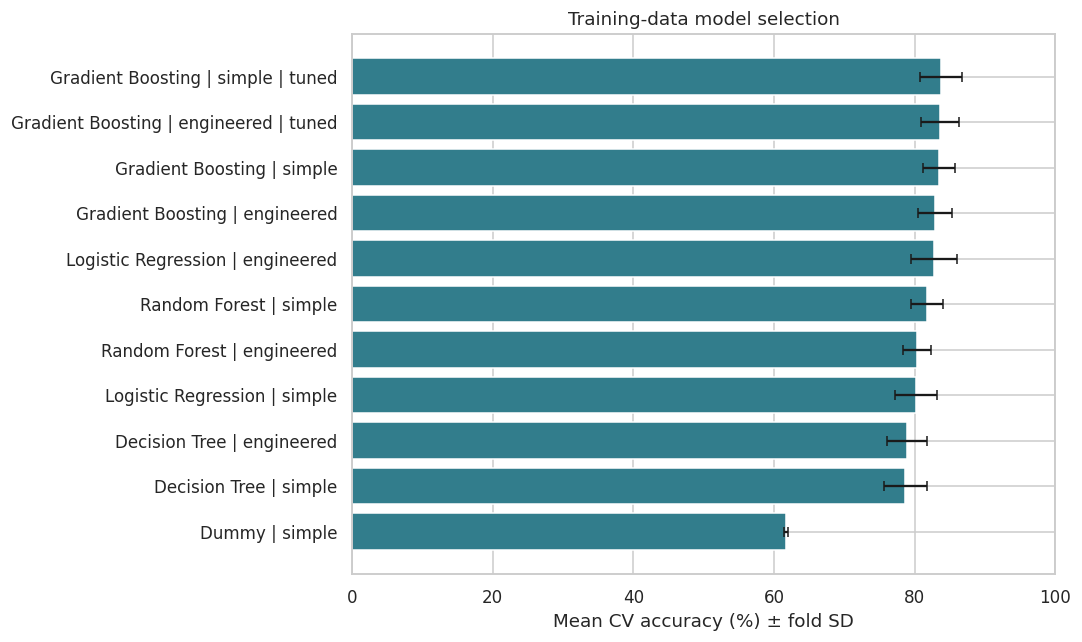

In [12]:
winner_name = selection_results.loc[selection_results['model'] != 'Dummy', 'candidate'].iloc[0]
simple_name = initial_results.loc[
    (initial_results['features'] == 'simple') & (initial_results['model'] != 'Dummy'), 'candidate'
].iloc[0]
final_model = clone(candidates[winner_name]).fit(X_train, y_train)
simple_model = clone(candidates[simple_name]).fit(X_train, y_train)
dummy_model = clone(candidates['Dummy | simple']).fit(X_train, y_train)

print('Frozen final candidate:', winner_name)
print('Frozen simple comparator:', simple_name)
winner_cv = selection_results.loc[selection_results['candidate'] == winner_name].iloc[0]
print(f"Selection CV accuracy: {winner_cv['cv_accuracy']:.2%} ± {winner_cv['cv_std']:.2%} fold SD")
print(f"Mean training minus CV accuracy: {winner_cv['train_cv_gap']:.2%}")

plot_rows = selection_results.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_rows['candidate'], plot_rows['cv_accuracy'] * 100,
        xerr=plot_rows['cv_std'] * 100, color='#327d8c', capsize=3)
ax.set(xlabel='Mean CV accuracy (%) ± fold SD', title='Training-data model selection', xlim=(0, 100))
plt.tight_layout()
plt.show()

## 10. Held-out evaluation

Evaluate the selected model, simple-feature comparator, and majority baseline on the same test passengers. The final model remains the CV-selected candidate even if another model scores higher on this test split.

| Metric | What it measures |
|---|---|
| Accuracy | Proportion of all passengers classified correctly |
| Precision | Proportion of predicted survivors who survived |
| Recall | Proportion of actual survivors identified |
| F1 | Harmonic mean of survivor precision and recall |
| Balanced accuracy | Mean recall across both classes |
| ROC-AUC | Ability to rank survivors above non-survivors across thresholds |

The model uses its default decision rule. The approximate Wilson interval describes uncertainty in test accuracy under an independent-passenger assumption; it does not include model-selection or family-group uncertainty.

In [13]:
def evaluate(model, features, target):
    predicted = model.predict(features)
    positive_index = list(model.classes_).index(1)
    probability = model.predict_proba(features)[:, positive_index]
    metrics = {
        'accuracy': accuracy_score(target, predicted),
        'precision': precision_score(target, predicted, zero_division=0),
        'recall': recall_score(target, predicted, zero_division=0),
        'f1': f1_score(target, predicted, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(target, predicted),
        'roc_auc': roc_auc_score(target, probability),
    }
    return metrics, predicted, probability

final_metrics, test_prediction, test_probability = evaluate(final_model, X_test, y_test)
simple_metrics, _, _ = evaluate(simple_model, X_test, y_test)
dummy_metrics, _, _ = evaluate(dummy_model, X_test, y_test)

# Fixed reporting order: do not reselect the winner based on this table.
test_results = pd.DataFrame([
    {'role': 'CV-selected final', 'candidate': winner_name, **final_metrics},
    {'role': 'Simple comparator', 'candidate': simple_name, **simple_metrics},
    {'role': 'Majority baseline', 'candidate': 'Dummy | simple', **dummy_metrics},
])
test_display = test_results.copy()
for metric in final_metrics:
    test_display[metric] = test_display[metric].map(lambda value: f'{value:.2%}')
display(test_display)

correct = int((test_prediction == y_test.to_numpy()).sum())
n = len(y_test)
p = correct / n
z = 1.96
denom = 1 + z**2 / n
center = (p + z**2 / (2*n)) / denom
half = z * np.sqrt(p*(1-p)/n + z**2/(4*n*n)) / denom
print(f'Final accuracy: {correct}/{n} = {p:.2%}')
print(f'Approximate 95% Wilson interval: {center-half:.2%} to {center+half:.2%}')
delta = final_metrics['accuracy'] - simple_metrics['accuracy']
print(f'Accuracy difference versus same-split simple comparator: {delta*100:+.2f} percentage points')
print('Class-wise report:')
print(classification_report(y_test, test_prediction, labels=[0, 1],
                            target_names=['Did not survive', 'Survived'], zero_division=0))

,role,candidate,accuracy,precision,recall,f1,balanced_accuracy,roc_auc
0,CV-selected final,Gradient Boosting | simple | tuned,81.01%,87.23%,59.42%,70.69%,76.98%,82.63%
1,Simple comparator,Gradient Boosting | simple,82.68%,86.54%,65.22%,74.38%,79.43%,83.37%
2,Majority baseline,Dummy | simple,61.45%,0.00%,0.00%,0.00%,50.00%,50.00%


Final accuracy: 145/179 = 81.01%
Approximate 95% Wilson interval: 74.63% to 86.08%
Accuracy difference versus same-split simple comparator: -1.68 percentage points
Class-wise report:
                 precision    recall  f1-score   support

Did not survive       0.79      0.95      0.86       110
       Survived       0.87      0.59      0.71        69

       accuracy                           0.81       179
      macro avg       0.83      0.77      0.78       179
   weighted avg       0.82      0.81      0.80       179



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


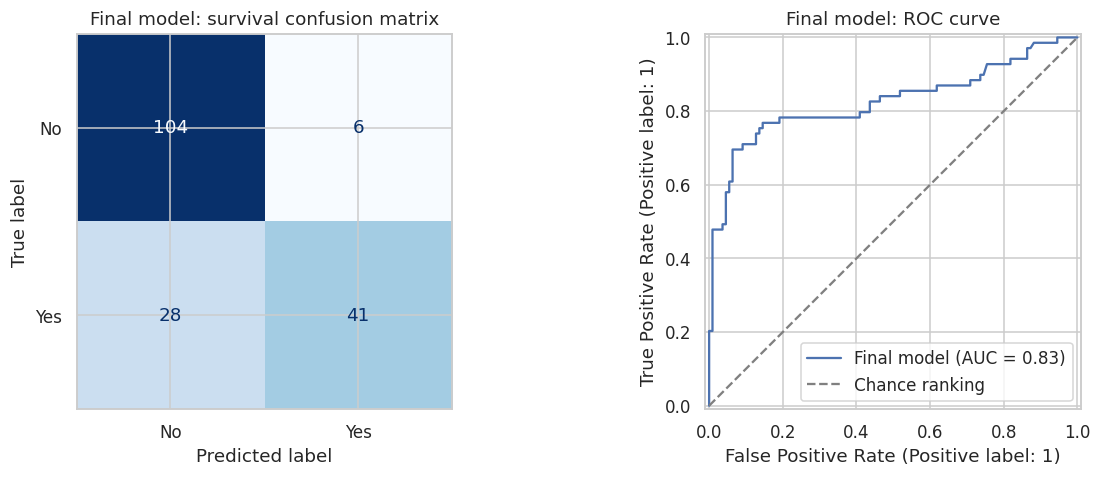

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_prediction, labels=[0, 1], display_labels=['No', 'Yes'],
    cmap='Blues', colorbar=False, ax=axes[0]
)
axes[0].set_title('Final model: survival confusion matrix')
RocCurveDisplay.from_predictions(y_test, test_probability, name='Final model', ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance ranking')
axes[1].set_title('Final model: ROC curve')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Error analysis

Inspect the ten misclassified test passengers with the highest prediction confidence. The confusion matrix and class-level report help distinguish missed survivors from incorrect survival predictions.

This analysis describes the completed evaluation; it is not used to retune the model on test results. Predicted probabilities have not been separately calibrated.

In [15]:
test_predictions = X_test[['PassengerId', 'Pclass', 'Sex', 'Age', 'Fare']].copy()
test_predictions['actual'] = y_test
test_predictions['predicted'] = test_prediction
test_predictions['survival_probability'] = test_probability
test_predictions['correct'] = test_predictions['actual'].eq(test_predictions['predicted'])
errors = test_predictions.loc[~test_predictions['correct']].copy()
errors['confidence_in_prediction'] = np.where(
    errors['predicted'].eq(1), errors['survival_probability'], 1-errors['survival_probability']
)
display(errors.sort_values('confidence_in_prediction', ascending=False).head(10).round(3))
print(f'Errors: {len(errors)} of {len(y_test)} test passengers.')
print('These probabilities have not been separately calibrated.')

,PassengerId,Pclass,Sex,Age,Fare,actual,predicted,survival_probability,correct,confidence_in_prediction
804,805,3,male,27.0,6.975,1,0,0.074,False,0.926
36,37,3,male,NaN,7.229,1,0,0.080,False,0.920
553,554,3,male,22.0,7.225,1,0,0.082,False,0.918
762,763,3,male,20.0,7.229,1,0,0.083,False,0.917
297,298,1,female,2.0,151.550,0,1,0.915,False,0.915
338,339,3,male,45.0,8.050,1,0,0.097,False,0.903
444,445,3,male,NaN,8.113,1,0,0.103,False,0.897
821,822,3,male,27.0,8.662,1,0,0.103,False,0.897
288,289,2,male,42.0,13.000,1,0,0.103,False,0.897
204,205,3,male,18.0,8.050,1,0,0.106,False,0.894


Errors: 34 of 179 test passengers.
These probabilities have not been separately calibrated.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 12. Passenger predictions

The fitted pipeline accepts raw passenger rows and applies its feature construction and learned preprocessing automatically. The example uses three test rows to demonstrate the prediction interface; it is not an additional evaluation.

For a separate CSV, set `NEW_PASSENGERS_PATH`. Required input columns must be present, while supported missing feature values are imputed by the pipeline. Predictions include the survival class and its estimated probability.

In [16]:
def predict_passengers(fitted_model, passengers):
    required_inputs = set(X.columns) - {'PassengerId', 'Ticket'}
    missing = sorted(required_inputs - set(passengers.columns))
    if missing:
        raise ValueError(f'Missing prediction columns: {missing}')
    clean_input = passengers.drop(columns=['Survived'], errors='ignore')
    output = pd.DataFrame(index=passengers.index)
    if 'PassengerId' in passengers:
        output['PassengerId'] = passengers['PassengerId']
    output['Survived'] = fitted_model.predict(clean_input)
    output['SurvivalProbability'] = fitted_model.predict_proba(clean_input)[:, list(fitted_model.classes_).index(1)]
    return output

display(predict_passengers(final_model, X_test.head(3)))

NEW_PASSENGERS_PATH = None  # Example: 'new_passengers.csv' or Kaggle's separate 'test.csv'
if NEW_PASSENGERS_PATH is not None:
    new_passengers = pd.read_csv(NEW_PASSENGERS_PATH)
    new_predictions = predict_passengers(final_model, new_passengers)
    display(new_predictions.head())
    # For Kaggle submission, use only PassengerId and Survived:
    # new_predictions[['PassengerId', 'Survived']].to_csv('submission.csv', index=False)

,PassengerId,Survived,SurvivalProbability
517,518,0,0.132549
71,72,0,0.167399
550,551,0,0.357858


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 13. Reproducibility and exports

Record the dataset fingerprint, package versions, split identifiers, model parameters, and evaluation metrics. Set `EXPORT_RESULTS = True` to save cross-validation results, test metrics, passenger predictions, and the run record locally.

The evaluated model remains fitted on the training partition. The complete dataset is not embedded in the notebook outputs.

In [17]:
run_record = {
    'dataset_filename': DATA_PATH.name,
    'dataset_sha256': data_sha256,
    'versions': versions,
    'seed': SEED, 'test_size': TEST_SIZE, 'cv_folds': CV_FOLDS,
    'search_iterations_per_candidate': SEARCH_ITERATIONS,
    'selection_metric': 'mean training-CV accuracy',
    'selected_candidate': winner_name,
    'model_parameters': final_model.named_steps['model'].get_params(),
    'training_passenger_ids': X_train['PassengerId'].tolist(),
    'test_passenger_ids': X_test['PassengerId'].tolist(),
    'selected_cv_accuracy': float(winner_cv['cv_accuracy']),
    'selected_cv_fold_sd': float(winner_cv['cv_std']),
    'final_test_metrics': final_metrics,
    'simple_comparator': simple_name,
    'simple_comparator_test_metrics': simple_metrics,
}

EXPORT_RESULTS = False  # Set True to create these small files in your own session.
if EXPORT_RESULTS:
    output_dir = Path('titanic_results')
    output_dir.mkdir(exist_ok=True)
    selection_results.to_csv(output_dir / 'cross_validation_results.csv', index=False)
    test_results.to_csv(output_dir / 'test_metrics.csv', index=False)
    test_predictions.to_csv(output_dir / 'test_predictions.csv', index=False)
    (output_dir / 'run_record.json').write_text(json.dumps(run_record, indent=2), encoding='utf-8')
    print('Results exported to:', output_dir.resolve())
else:
    print('Exports disabled. The notebook outputs already contain the measured results.')

Exports disabled. The notebook outputs already contain the measured results.


## 14. Results summary

The following cell reports the selected candidate and measured scores directly from the run variables.

In the saved run, the selected model achieved **81.01% test accuracy**, **87.23% survivor precision**, and **59.42% survivor recall**. Its **70.69% survivor F1** reflects the trade-off between those two metrics. The simple-feature comparator achieved **82.68% test accuracy**; this test result does not replace the CV-based selection decision.

In [18]:
print('Selected by training CV:', winner_name)
print(f"CV selection accuracy: {winner_cv['cv_accuracy']:.2%}")
print(f"Held-out accuracy: {final_metrics['accuracy']:.2%}; survivor F1: {final_metrics['f1']:.2%}")
if delta > 0:
    print(f'The selected model exceeded the simple comparator by {delta*100:.2f} percentage points on this test split.')
elif delta < 0:
    print(f'The selected model was {-delta*100:.2f} percentage points below the simple comparator on this test split.')
    print('The CV-selected model is retained; the test result is not used to choose another winner.')
else:
    print('The selected model and simple comparator had equal test accuracy.')
print('This difference alone does not establish a statistically reliable or universal improvement.')


Selected by training CV: Gradient Boosting | simple | tuned
CV selection accuracy: 83.70%
Held-out accuracy: 81.01%; survivor F1: 70.69%
The selected model was 1.68 percentage points below the simple comparator on this test split.
The CV-selected model is retained; the test result is not used to choose another winner.
This difference alone does not establish a statistically reliable or universal improvement.


## Limitations

This experiment uses a small historical dataset and a single held-out split. Prior exposure to the dataset, family or ticket dependence, and selection across multiple CV candidates limit how broadly the results can be interpreted. Probabilities are uncalibrated, and no external validation is included.

### Technical references

- [pandas correlation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)
- [scikit-learn pipelines and leakage prevention](https://scikit-learn.org/stable/common_pitfalls.html)
- [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
- [RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)